<a href="https://colab.research.google.com/github/susmitsingh01/cuda-triton-llm-kernels/blob/main/01_vadd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01 : Vector Add

## Prediction
- Operation: c = a + b, n elements, fp32
- Bytes moved: read a, b (8 bytes) + write c (4 bytes) = **12n bytes**
- Work: **n FLOPs** (one add per element)
- Arithmetic intensity: 1/12 ≈ **0.083 FLOP/byte**
  (T4 balance point ≈ 8 TFLOP/s ÷ 320 GB/s ≈ 25 FLOP/byte)
- **Prediction: memory-bound.** Best possible time ≈ 12n ÷ achievable bandwidth.
- Target: effective bandwidth as % of measured peak (copy kernel, measured later).

## Environment logging




In [30]:
import pandas as pd

In [31]:
import platform
import subprocess

import torch
import triton


def env_info():
    smi = subprocess.run(
        ["nvidia-smi",
         "--query-gpu=name,driver_version,clocks.sm,clocks.mem,ecc.mode.current",
         "--format=csv,noheader"],
        capture_output=True, text=True,
    ).stdout.strip()
    return {
        "gpu": smi,
        "torch": torch.__version__,
        "cuda": torch.version.cuda,
        "triton": triton.__version__,
        "python": platform.python_version(),
    }

In [32]:
env_info()

{'gpu': 'Tesla T4, 580.82.07, 585 MHz, 5000 MHz, Enabled',
 'torch': '2.11.0+cu130',
 'cuda': '13.0',
 'triton': '3.6.0',
 'python': '3.13.15'}

## PyTorch reference

In [33]:
import torch

def vadd_ref(a, b):
    return a + b

# sanity check
a = torch.randn(1024, device="cuda")
b = torch.randn(1024, device="cuda")
print(torch.equal(vadd_ref(a, b), a + b))

True


In [34]:
def check(fn, ref, sizes=(1, 127, 4096, 2**24 + 3), dtype=torch.float32):
    for n in sizes:
        a = torch.randn(n, device="cuda", dtype=dtype)
        b = torch.randn(n, device="cuda", dtype=dtype)
        torch.testing.assert_close(fn(a, b), ref(a, b))
    print(f"{fn.__name__}: {len(sizes)} sizes passed")

check(vadd_ref, vadd_ref)   # to check if the function itself is good enough

vadd_ref: 4 sizes passed


In [35]:
import pandas as pd
from triton.testing import do_bench

def bench(impls, sizes, bytes_per_elem=12, dtype=torch.float32):
    rows = []
    for n in sizes:
        a = torch.randn(n, device="cuda", dtype=dtype)
        b = torch.randn(n, device="cuda", dtype=dtype)
        for name, fn in impls.items():
            fn(a, b)                                    # warm call (compile, allocate)
            ms = do_bench(lambda: fn(a, b), return_mode="median")
            gbps = bytes_per_elem * n / (ms * 1e-3) / 1e9
            rows.append({"impl": name, "n": n, "time_us": ms * 1e3, "GB/s": gbps})
    df = pd.DataFrame(rows)
    print(env_info())
    return df

In [36]:
def time_ms(fn, warmup=25, iters=100):
    flush = torch.empty(256 * 1024 * 1024, dtype=torch.uint8, device="cuda")   # 256 MB
    for _ in range(warmup):
        fn()
    torch.cuda.synchronize()

    start = torch.cuda.Event(enable_timing=True)
    stop = torch.cuda.Event(enable_timing=True)
    times = []
    for _ in range(iters):
        flush.zero_()                         # push inputs out of L2
        start.record()                        # marker before the kernel
        fn()
        stop.record()                         # marker after the kernel
        stop.synchronize()                    # wait until the GPU reaches 'stop'
        times.append(start.elapsed_time(stop))
    times.sort()
    return times[iters // 2]                  # median, in ms


def bench(impls, sizes, bytes_per_elem=12, dtype=torch.float32):
    rows = []
    for n in sizes:
        a = torch.randn(n, device="cuda", dtype=dtype)
        b = torch.randn(n, device="cuda", dtype=dtype)
        c = torch.empty_like(a)                         # preallocated output, like C++
        for name, fn in impls.items():
            fn(a, b, c)                                 # warm call (compile etc.)
            ms = time_ms(lambda: fn(a, b, c))
            gbps = bytes_per_elem * n / (ms * 1e-3) / 1e9
            rows.append({"impl": name, "n": n, "time_us": ms * 1e3, "GB/s": gbps})
    print(env_info())
    return pd.DataFrame(rows)

In [37]:
import torch._dynamo
torch._dynamo.reset()
torch._dynamo.config.recompile_limit = 64

sizes = [2**k for k in range(10, 29)]

def torch_eager(a, b, c):
    torch.add(a, b, out=c)

def add_into(a, b, c):
    c.copy_(a + b)

compile_static = torch.compile(add_into, dynamic=False)

def format_n_as_power_of_2(n):
    if n == 0: return '2**0'
    k = 0
    temp_n = n
    while temp_n % 2 == 0 and temp_n > 1:
        temp_n //= 2
        k += 1
    if temp_n == 1:
        return f'2**{k}'
    else:
        # Fallback for numbers not exact powers of 2, though in this case they should be.
        return str(n)

df_py = bench({"torch_eager": torch_eager, "compile_static": compile_static}, sizes)
df_py['n'] = df_py['n'].apply(format_n_as_power_of_2)
display(df_py)

{'gpu': 'Tesla T4, 580.82.07, 1050 MHz, 5000 MHz, Enabled', 'torch': '2.11.0+cu130', 'cuda': '13.0', 'triton': '3.6.0', 'python': '3.13.15'}


,impl,n,time_us,GB/s
0,torch_eager,2**10,6.816000,1.802817
1,compile_static,2**10,6.112000,2.010471
2,torch_eager,2**11,6.048000,4.063492
3,compile_static,2**11,4.192000,5.862596
4,torch_eager,2**12,4.448000,11.050360
5,compile_static,2**12,4.192000,11.725191
6,torch_eager,2**13,4.480000,21.942857
7,compile_static,2**13,4.128000,23.813955
8,torch_eager,2**14,5.728000,34.324023
9,compile_static,2**14,5.376000,36.571429


In [38]:
%%writefile vadd_v0.cu
#include <stdio.h>
#include <stdlib.h>
#include <math.h>
#include <algorithm>

// if a CUDA call fails, print the error and stop
#define CHECK(call)                                                      \
    {                                                                    \
        cudaError_t err = (call);                                        \
        if (err != cudaSuccess) {                                        \
            printf("%s in %s at line %d\n", cudaGetErrorString(err),     \
                   __FILE__, __LINE__);                                  \
            exit(EXIT_FAILURE);                                          \
        }                                                                \
    }

// Kernel: each thread adds one element
__global__ void vecAddKernel(float* A, float* B, float* C, int n) {
    int i = threadIdx.x + blockDim.x * blockIdx.x;
    if (i < n) {
        C[i] = A[i] + B[i];
    }
}

Writing vadd_v0.cu


In [39]:
%%writefile -a vadd_v0.cu

// Host function: allocate device memory, copy inputs, launch, copy result back, free
void vecAdd(float* A_h, float* B_h, float* C_h, int n) {
    int size = n * sizeof(float);
    float *A_d, *B_d, *C_d;

    CHECK(cudaMalloc((void**)&A_d, size));
    CHECK(cudaMalloc((void**)&B_d, size));
    CHECK(cudaMalloc((void**)&C_d, size));

    CHECK(cudaMemcpy(A_d, A_h, size, cudaMemcpyHostToDevice));
    CHECK(cudaMemcpy(B_d, B_h, size, cudaMemcpyHostToDevice));

    vecAddKernel<<<ceil(n / 256.0), 256>>>(A_d, B_d, C_d, n);
    CHECK(cudaGetLastError());

    CHECK(cudaMemcpy(C_h, C_d, size, cudaMemcpyDeviceToHost));

    CHECK(cudaFree(A_d));
    CHECK(cudaFree(B_d));
    CHECK(cudaFree(C_d));
}

Appending to vadd_v0.cu


In [40]:
%%writefile -a vadd_v0.cu

// CPU reference: the answer we trust
void vecAddCPU(float* A, float* B, float* C, int n) {
    for (int i = 0; i < n; i++) {
        C[i] = A[i] + B[i];
    }
}

// Run GPU and CPU on the same inputs, compare every element
int checkCorrectness(int n) {
    float* A_h   = (float*)malloc(n * sizeof(float));
    float* B_h   = (float*)malloc(n * sizeof(float));
    float* C_h   = (float*)malloc(n * sizeof(float));   // GPU result
    float* C_ref = (float*)malloc(n * sizeof(float));   // CPU result

    for (int i = 0; i < n; i++) {
        A_h[i] = rand() / (float)RAND_MAX;   // random value between 0 and 1
        B_h[i] = rand() / (float)RAND_MAX;
    }

    vecAdd(A_h, B_h, C_h, n);          // GPU
    vecAddCPU(A_h, B_h, C_ref, n);     // CPU

    int errors = 0;
    for (int i = 0; i < n; i++) {
        if (fabs(C_h[i] - C_ref[i]) > 1e-5) {
            errors++;
        }
    }
    printf("# check n=%d: %s (%d mismatches)\n", n, errors == 0 ? "PASS" : "FAIL", errors);

    free(A_h);
    free(B_h);
    free(C_h);
    free(C_ref);
    return errors == 0;
}

Appending to vadd_v0.cu


In [41]:
%%writefile -a vadd_v0.cu

#define WARMUP 25
#define ITERS 100

// Time only the kernel: warm-up, then ITERS timed runs, each after an L2 flush.
// Returns the median time in milliseconds.
float timeKernel(int n) {
    int size = n * sizeof(float);
    float *A_d, *B_d, *C_d;
    CHECK(cudaMalloc((void**)&A_d, size));
    CHECK(cudaMalloc((void**)&B_d, size));
    CHECK(cudaMalloc((void**)&C_d, size));
    CHECK(cudaMemset(A_d, 0, size));   // give the inputs known values
    CHECK(cudaMemset(B_d, 0, size));

    int flushSize = 256 * 1024 * 1024;   // 256 MB, much larger than the T4's 4 MB L2
    char* flush_d;
    CHECK(cudaMalloc((void**)&flush_d, flushSize));

    int blocks = ceil(n / 256.0);

    // Warm-up runs (not timed)
    for (int i = 0; i < WARMUP; i++) {
        vecAddKernel<<<blocks, 256>>>(A_d, B_d, C_d, n);
    }
    CHECK(cudaDeviceSynchronize());

    cudaEvent_t start, stop;
    CHECK(cudaEventCreate(&start));
    CHECK(cudaEventCreate(&stop));

    float times[ITERS];
    for (int i = 0; i < ITERS; i++) {
        CHECK(cudaMemset(flush_d, 0, flushSize));             // push A, B, C out of L2
        CHECK(cudaEventRecord(start));                        // marker before the kernel
        vecAddKernel<<<blocks, 256>>>(A_d, B_d, C_d, n);
        CHECK(cudaEventRecord(stop));                         // marker after the kernel
        CHECK(cudaEventSynchronize(stop));                    // wait until the GPU reaches 'stop'
        CHECK(cudaEventElapsedTime(&times[i], start, stop));  // time between the markers
    }
    CHECK(cudaGetLastError());

    std::sort(times, times + ITERS);   // smallest to largest

    CHECK(cudaEventDestroy(start));
    CHECK(cudaEventDestroy(stop));
    CHECK(cudaFree(A_d));
    CHECK(cudaFree(B_d));
    CHECK(cudaFree(C_d));
    CHECK(cudaFree(flush_d));

    return times[ITERS / 2];   // median
}

Appending to vadd_v0.cu


In [42]:
%%writefile -a vadd_v0.cu

// Profile mode: run the kernel exactly once at size n, so ncu has a single launch to profile
void profileOnce(int n) {
    int size = n * sizeof(float);
    float *A_d, *B_d, *C_d;
    CHECK(cudaMalloc((void**)&A_d, size));
    CHECK(cudaMalloc((void**)&B_d, size));
    CHECK(cudaMalloc((void**)&C_d, size));
    CHECK(cudaMemset(A_d, 0, size));
    CHECK(cudaMemset(B_d, 0, size));

    vecAddKernel<<<ceil(n / 256.0), 256>>>(A_d, B_d, C_d, n);
    CHECK(cudaGetLastError());
    CHECK(cudaDeviceSynchronize());

    CHECK(cudaFree(A_d));
    CHECK(cudaFree(B_d));
    CHECK(cudaFree(C_d));
}

int main(int argc, char** argv) {
    // ./vadd_v0 <n>  ->  profile mode: one launch at size n
    if (argc == 2) {
        int n = atoi(argv[1]);
        profileOnce(n);
        return 0;
    }
    int benchSizes[] = {1 << 10, 1 << 11, 1 << 12, 1 << 13, 1 << 14, 1 << 15, 1 << 16,
                    1 << 17, 1 << 18, 1 << 19, 1 << 20, 1 << 21, 1 << 22, 1 << 23,
                    1 << 24, 1 << 25, 1 << 26, 1 << 27, 1 << 28};
    int numSizes = sizeof(benchSizes) / sizeof(benchSizes[0]);   // number of elements in the array

    // Define checkSizes array for correctness checks
    int checkSizes[] = {1 << 10, 1 << 11, 1 << 12, 1 << 13}; // Using first few elements of benchSizes

    // 1) Correctness first; stop if anything fails
    int allPassed = 1;
    for (int k = 0; k < 4; k++) {
        if (!checkCorrectness(checkSizes[k])) {
            allPassed = 0;
        }
    }
    if (!allPassed) {
        printf("# correctness failed, not benchmarking\n");
        return 1;
    }

    // 2) Benchmark
    printf("impl,n,time_us,GB/s\n");
    for (int k = 0; k < numSizes; k++) { // Loop over all benchSizes
        int n = benchSizes[k];
        float ms = timeKernel(n);
        float gbps = 12.0f * n / (ms * 1e-3f) / 1e9f;   // bytes moved / seconds / 1e9
        printf("cuda_v0,%d,%.3f,%.2f\n", n, ms * 1000.0f, gbps);
    }
    return 0;
}

Appending to vadd_v0.cu


In [43]:
!nvcc -O3 -arch=native -lineinfo -o vadd_v0 vadd_v0.cu && ./vadd_v0 | tee cuda_v0.csv

# check n=1024: PASS (0 mismatches)
# check n=2048: PASS (0 mismatches)
# check n=4096: PASS (0 mismatches)
# check n=8192: PASS (0 mismatches)
impl,n,time_us,GB/s
cuda_v0,1024,4.320,2.84
cuda_v0,2048,4.928,4.99
cuda_v0,4096,4.576,10.74
cuda_v0,8192,4.832,20.34
cuda_v0,16384,5.536,35.51
cuda_v0,32768,6.624,59.36
cuda_v0,65536,8.768,89.69
cuda_v0,131072,12.416,126.68
cuda_v0,262144,18.592,169.20
cuda_v0,524288,31.264,201.24
cuda_v0,1048576,55.392,227.16
cuda_v0,2097152,104.448,240.94
cuda_v0,4194304,200.128,251.50
cuda_v0,8388608,391.808,256.92
cuda_v0,16777216,781.792,257.52
cuda_v0,33554432,1545.888,260.47
cuda_v0,67108864,3090.720,260.56
cuda_v0,134217728,6168.576,261.10
cuda_v0,268435456,12339.296,261.05


In [44]:
df_cuda = pd.read_csv("cuda_v0.csv", comment="#")
df_cuda['n'] = df_cuda['n'].apply(format_n_as_power_of_2)
pd.concat([df_py, df_cuda]).sort_values(["n", "impl"])

,impl,n,time_us,GB/s
1,compile_static,2**10,6.112000,2.010471
0,cuda_v0,2**10,4.320000,2.840000
0,torch_eager,2**10,6.816000,1.802817
3,compile_static,2**11,4.192000,5.862596
1,cuda_v0,2**11,4.928000,4.990000
2,torch_eager,2**11,6.048000,4.063492
5,compile_static,2**12,4.192000,11.725191
2,cuda_v0,2**12,4.576000,10.740000
4,torch_eager,2**12,4.448000,11.050360
7,compile_static,2**13,4.128000,23.813955


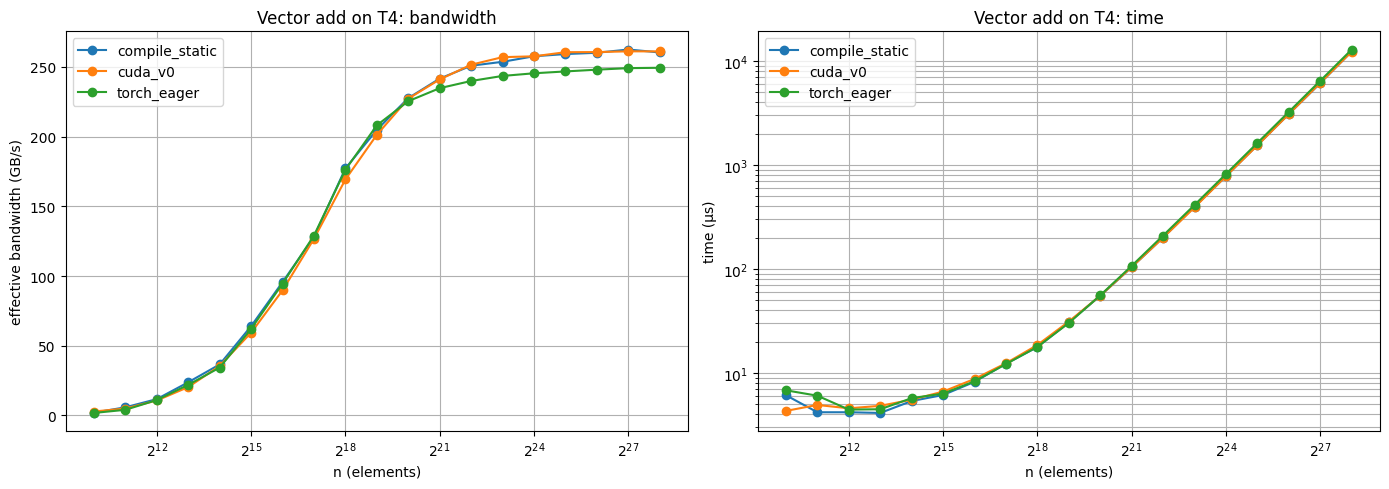

In [45]:
import matplotlib.pyplot as plt

df_all = pd.concat([df_py, pd.read_csv("cuda_v0.csv", comment="#")], ignore_index=True)

# make sure n is a number (handles values written as "2**10")
df_all["n"] = df_all["n"].apply(lambda x: 2 ** int(x.split("**")[1]) if isinstance(x, str) else x)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for impl, g in df_all.groupby("impl"):
    g = g.sort_values("n")
    ax1.plot(g["n"], g["GB/s"], marker="o", label=impl)
    ax2.plot(g["n"], g["time_us"], marker="o", label=impl)

ax1.set_xscale("log", base=2)
ax1.set_xlabel("n (elements)")
ax1.set_ylabel("effective bandwidth (GB/s)")
ax1.set_title("Vector add on T4: bandwidth")
ax1.grid(True)
ax1.legend()

ax2.set_xscale("log", base=2)
ax2.set_yscale("log")
ax2.set_xlabel("n (elements)")
ax2.set_ylabel("time (µs)")
ax2.set_title("Vector add on T4: time")
ax2.grid(True, which="both")
ax2.legend()

plt.tight_layout()
plt.savefig("vadd_t4.png", dpi=150)   # saved so it can go into the writeup
plt.show()

Vector add on the T4 is fully described by a ~5 µs fixed GPU-side cost and a ~257 GB/s bandwidth ceiling (time = 5 µs + 12n ÷ 257 GB/s): below ~2¹⁵ elements the fixed cost dominates, and above ~2²¹ the kernel is purely bandwidth-bound. All implementations are identical up to ~2¹⁹; at large sizes, the naive CUDA kernel plateaus at ~257 GB/s vs. ~241 GB/s for PyTorch eager, a ~6% gap to investigate with ncu.

In [18]:
!ncu --metrics smsp__inst_issued.sum,smsp__inst_executed.sum ./vadd_v0 4096

==PROF== Connected to process 1198 (/content/vadd_v0)
==PROF== Profiling "vecAddKernel" - 0: 0%....50%....100% - 1 pass
==PROF== Disconnected from process 1198
[1198] vadd_v0@127.0.0.1
  vecAddKernel(float *, float *, float *, int) (16, 1, 1)x(256, 1, 1), Context 1, Stream 7, Device 0, CC 7.5
    Section: Command line profiler metrics
    ----------------------- ----------- ------------
    Metric Name             Metric Unit Metric Value
    ----------------------- ----------- ------------
    smsp__inst_executed.sum        inst        1,920
    smsp__inst_issued.sum          inst        2,304
    ----------------------- ----------- ------------



In [17]:
!ncu --section SpeedOfLight --section LaunchStats --section Occupancy --section WarpStateStats ./vadd_v0 4096

==PROF== Connected to process 1132 (/content/vadd_v0)
==PROF== Profiling "vecAddKernel" - 0: 0%....50%....100% - 12 passes
==PROF== Disconnected from process 1132
[1132] vadd_v0@127.0.0.1
  vecAddKernel(float *, float *, float *, int) (16, 1, 1)x(256, 1, 1), Context 1, Stream 7, Device 0, CC 7.5
    Section: GPU Speed Of Light Throughput
    ----------------------- ----------- ------------
    Metric Name             Metric Unit Metric Value
    ----------------------- ----------- ------------
    DRAM Frequency                  Ghz         4.89
    SM Frequency                    Mhz       574.43
    Elapsed Cycles                cycle        2,226
    Memory Throughput                 %         3.26
    DRAM Throughput                   %         3.26
    Duration                         us         3.87
    L1/TEX Cache Throughput           %         6.36
    L2 Cache Throughput               %         2.31
    SM Active Cycles              cycle       402.45
    Compute (SM) Through

In [19]:
!ncu --section SpeedOfLight --section LaunchStats --section Occupancy --section WarpStateStats --section MemoryWorkloadAnalysis --metrics smsp__inst_issued.sum,smsp__inst_executed.sum ./vadd_v0 131072

==PROF== Connected to process 3018 (/content/vadd_v0)
==PROF== Profiling "vecAddKernel" - 0: 0%....50%....100% - 13 passes
==PROF== Disconnected from process 3018
[3018] vadd_v0@127.0.0.1
  vecAddKernel(float *, float *, float *, int) (512, 1, 1)x(256, 1, 1), Context 1, Stream 7, Device 0, CC 7.5
    Section: Command line profiler metrics
    ----------------------- ----------- ------------
    Metric Name             Metric Unit Metric Value
    ----------------------- ----------- ------------
    smsp__inst_executed.sum        inst       61,440
    smsp__inst_issued.sum          inst       65,280
    ----------------------- ----------- ------------

    Section: GPU Speed Of Light Throughput
    ----------------------- ----------- ------------
    Metric Name             Metric Unit Metric Value
    ----------------------- ----------- ------------
    DRAM Frequency                  Ghz         4.62
    SM Frequency                    Mhz       591.96
    Elapsed Cycles              

In [20]:
!ncu --section SpeedOfLight --section LaunchStats --section Occupancy --section WarpStateStats --section MemoryWorkloadAnalysis --metrics smsp__inst_issued.sum,smsp__inst_executed.sum ./vadd_v0 16777216

==PROF== Connected to process 3194 (/content/vadd_v0)
==PROF== Profiling "vecAddKernel" - 0: 0%....50%....100% - 13 passes
==PROF== Disconnected from process 3194
[3194] vadd_v0@127.0.0.1
  vecAddKernel(float *, float *, float *, int) (65536, 1, 1)x(256, 1, 1), Context 1, Stream 7, Device 0, CC 7.5
    Section: Command line profiler metrics
    ----------------------- ----------- ------------
    Metric Name             Metric Unit Metric Value
    ----------------------- ----------- ------------
    smsp__inst_executed.sum        inst    7,864,320
    smsp__inst_issued.sum          inst    7,868,160
    ----------------------- ----------- ------------

    Section: GPU Speed Of Light Throughput
    ----------------------- ----------- ------------
    Metric Name             Metric Unit Metric Value
    ----------------------- ----------- ------------
    DRAM Frequency                  Ghz         4.96
    SM Frequency                    Mhz       584.95
    Elapsed Cycles            

In [55]:
%%writefile vadd.cu
#include <stdio.h>
#include <stdlib.h>
#include <math.h>
#include <algorithm>

// PMPP-style error check: if a CUDA call fails, print the error and stop
#define CHECK(call)                                                      \
    {                                                                    \
        cudaError_t err = (call);                                        \
        if (err != cudaSuccess) {                                        \
            printf("%s in %s at line %d\n", cudaGetErrorString(err),     \
                   __FILE__, __LINE__);                                  \
            exit(EXIT_FAILURE);                                          \
        }                                                                \
    }

// v0: each thread adds one element
__global__ void vecAddKernel(float* A, float* B, float* C, int n) {
    int i = threadIdx.x + blockDim.x * blockIdx.x;
    if (i < n) {
        C[i] = A[i] + B[i];
    }
}

// v1: each thread adds 4 consecutive floats, using one 128-bit load per input
__global__ void vecAddKernel_v1(float* A, float* B, float* C, int n) {
    int i = threadIdx.x + blockDim.x * blockIdx.x;   // index of a group of 4 floats
    int n4 = n / 4;                                   // number of complete groups

    if (i < n4) {
        float4 a = reinterpret_cast<float4*>(A)[i];   // floats 4i .. 4i+3 of A
        float4 b = reinterpret_cast<float4*>(B)[i];
        float4 c;
        c.x = a.x + b.x;
        c.y = a.y + b.y;
        c.z = a.z + b.z;
        c.w = a.w + b.w;
        reinterpret_cast<float4*>(C)[i] = c;
    }

    // Tail: the last n % 4 elements, one each, handled by the first few threads
    int t = n4 * 4 + i;
    if (i < n % 4) {
        C[t] = A[t] + B[t];
    }
}

// Launcher: picks the kernel and its grid size by version number
void launchKernel(int version, float* A_d, float* B_d, float* C_d, int n) {
    if (version == 0) {
        vecAddKernel<<<ceil(n / 256.0), 256>>>(A_d, B_d, C_d, n);
    } else if (version == 1) {
        // one thread per group of 4, but at least enough threads for the tail
        int threadsNeeded = (n / 4 > n % 4) ? n / 4 : n % 4;
        vecAddKernel_v1<<<ceil(threadsNeeded / 256.0), 256>>>(A_d, B_d, C_d, n);
    }
}



Overwriting vadd.cu


In [56]:
%%writefile -a vadd.cu

// Host function: allocate device memory, copy inputs, launch, copy result back, free
void vecAdd(int version, float* A_h, float* B_h, float* C_h, int n) {
    int size = n * sizeof(float);
    float *A_d, *B_d, *C_d;

    CHECK(cudaMalloc((void**)&A_d, size));
    CHECK(cudaMalloc((void**)&B_d, size));
    CHECK(cudaMalloc((void**)&C_d, size));

    CHECK(cudaMemcpy(A_d, A_h, size, cudaMemcpyHostToDevice));
    CHECK(cudaMemcpy(B_d, B_h, size, cudaMemcpyHostToDevice));

    launchKernel(version, A_d, B_d, C_d, n);
    CHECK(cudaGetLastError());

    CHECK(cudaMemcpy(C_h, C_d, size, cudaMemcpyDeviceToHost));

    CHECK(cudaFree(A_d));
    CHECK(cudaFree(B_d));
    CHECK(cudaFree(C_d));
}

Appending to vadd.cu


In [57]:
%%writefile -a vadd.cu

// CPU reference: the answer we trust
void vecAddCPU(float* A, float* B, float* C, int n) {
    for (int i = 0; i < n; i++) {
        C[i] = A[i] + B[i];
    }
}

// Run GPU and CPU on the same inputs, compare every element
int checkCorrectness(int version, int n) {
    float* A_h   = (float*)malloc(n * sizeof(float));
    float* B_h   = (float*)malloc(n * sizeof(float));
    float* C_h   = (float*)malloc(n * sizeof(float));   // GPU result
    float* C_ref = (float*)malloc(n * sizeof(float));   // CPU result

    for (int i = 0; i < n; i++) {
        A_h[i] = rand() / (float)RAND_MAX;
        B_h[i] = rand() / (float)RAND_MAX;
    }

    vecAdd(version, A_h, B_h, C_h, n);   // GPU
    vecAddCPU(A_h, B_h, C_ref, n);       // CPU

    int errors = 0;
    for (int i = 0; i < n; i++) {
        if (fabs(C_h[i] - C_ref[i]) > 1e-5) {
            errors++;
        }
    }
    printf("# v%d check n=%d: %s (%d mismatches)\n",
           version, n, errors == 0 ? "PASS" : "FAIL", errors);

    free(A_h);
    free(B_h);
    free(C_h);
    free(C_ref);
    return errors == 0;
}

Appending to vadd.cu


In [58]:
%%writefile -a vadd.cu

#define WARMUP 25
#define ITERS 100

// Time only the kernel: warm-up, then ITERS timed runs, each after an L2 flush.
// Returns the median time in milliseconds.
float timeKernel(int version, int n) {
    int size = n * sizeof(float);
    float *A_d, *B_d, *C_d;
    CHECK(cudaMalloc((void**)&A_d, size));
    CHECK(cudaMalloc((void**)&B_d, size));
    CHECK(cudaMalloc((void**)&C_d, size));
    CHECK(cudaMemset(A_d, 0, size));   // give the inputs known values
    CHECK(cudaMemset(B_d, 0, size));

    int flushSize = 256 * 1024 * 1024;   // 256 MB, much larger than the T4's 4 MB L2
    char* flush_d;
    CHECK(cudaMalloc((void**)&flush_d, flushSize));

    // Warm-up runs (not timed)
    for (int i = 0; i < WARMUP; i++) {
        launchKernel(version, A_d, B_d, C_d, n);
    }
    CHECK(cudaDeviceSynchronize());

    cudaEvent_t start, stop;
    CHECK(cudaEventCreate(&start));
    CHECK(cudaEventCreate(&stop));

    float times[ITERS];
    for (int i = 0; i < ITERS; i++) {
        CHECK(cudaMemset(flush_d, 0, flushSize));             // push A, B, C out of L2
        CHECK(cudaEventRecord(start));                        // marker before the kernel
        launchKernel(version, A_d, B_d, C_d, n);
        CHECK(cudaEventRecord(stop));                         // marker after the kernel
        CHECK(cudaEventSynchronize(stop));                    // wait until the GPU reaches 'stop'
        CHECK(cudaEventElapsedTime(&times[i], start, stop));  // time between the markers
    }
    CHECK(cudaGetLastError());

    std::sort(times, times + ITERS);   // smallest to largest

    CHECK(cudaEventDestroy(start));
    CHECK(cudaEventDestroy(stop));
    CHECK(cudaFree(A_d));
    CHECK(cudaFree(B_d));
    CHECK(cudaFree(C_d));
    CHECK(cudaFree(flush_d));

    return times[ITERS / 2];   // median
}

Appending to vadd.cu


In [59]:
%%writefile -a vadd.cu

// Profile mode: run one version exactly once at size n, so ncu has a single launch
void profileOnce(int version, int n) {
    int size = n * sizeof(float);
    float *A_d, *B_d, *C_d;
    CHECK(cudaMalloc((void**)&A_d, size));
    CHECK(cudaMalloc((void**)&B_d, size));
    CHECK(cudaMalloc((void**)&C_d, size));
    CHECK(cudaMemset(A_d, 0, size));
    CHECK(cudaMemset(B_d, 0, size));

    launchKernel(version, A_d, B_d, C_d, n);
    CHECK(cudaGetLastError());
    CHECK(cudaDeviceSynchronize());

    CHECK(cudaFree(A_d));
    CHECK(cudaFree(B_d));
    CHECK(cudaFree(C_d));
}

int main(int argc, char** argv) {
    // ./vadd <version> <n>  ->  profile mode: one launch
    if (argc == 3) {
        int version = atoi(argv[1]);
        int n = atoi(argv[2]);
        profileOnce(version, n);
        return 0;
    }

    // ./vadd  ->  normal mode: correctness checks for every version, then benchmark
    int versions[] = {0, 1};
    int numVersions = sizeof(versions) / sizeof(versions[0]);

    int checkSizes[] = {1, 127, 4096, (1 << 24) + 3};
    int numCheckSizes = sizeof(checkSizes) / sizeof(checkSizes[0]);

    int benchSizes[] = {1 << 10, 1 << 11, 1 << 12, 1 << 13, 1 << 14, 1 << 15, 1 << 16,
                        1 << 17, 1 << 18, 1 << 19, 1 << 20, 1 << 21, 1 << 22, 1 << 23,
                        1 << 24, 1 << 25, 1 << 26, 1 << 27, 1 << 28};
    int numSizes = sizeof(benchSizes) / sizeof(benchSizes[0]);

    // 1) Correctness first; stop if anything fails
    int allPassed = 1;
    for (int v = 0; v < numVersions; v++) {
        for (int k = 0; k < numCheckSizes; k++) {
            if (!checkCorrectness(versions[v], checkSizes[k])) {
                allPassed = 0;
            }
        }
    }
    if (!allPassed) {
        printf("# correctness failed, not benchmarking\n");
        return 1;
    }

    // 2) Benchmark
    printf("impl,n,time_us,GB/s\n");
    for (int v = 0; v < numVersions; v++) {
        for (int k = 0; k < numSizes; k++) {
            int n = benchSizes[k];
            float ms = timeKernel(versions[v], n);
            float gbps = 12.0f * n / (ms * 1e-3f) / 1e9f;   // bytes moved / seconds / 1e9
            printf("cuda_v%d,%d,%.3f,%.2f\n", versions[v], n, ms * 1000.0f, gbps);
        }
    }
    return 0;
}

Appending to vadd.cu


In [12]:
!nvcc -O3 -arch=native -lineinfo -o vadd vadd.cu && ./vadd | tee cuda_vadd.csv

# v0 check n=1: PASS (0 mismatches)
# v0 check n=127: PASS (0 mismatches)
# v0 check n=4096: PASS (0 mismatches)
# v0 check n=16777219: PASS (0 mismatches)
# v1 check n=1: PASS (0 mismatches)
# v1 check n=127: PASS (0 mismatches)
# v1 check n=4096: PASS (0 mismatches)
# v1 check n=16777219: PASS (0 mismatches)
impl,n,time_us,GB/s
cuda_v0,1024,6.304,1.95
cuda_v0,2048,6.144,4.00
cuda_v0,4096,4.416,11.13
cuda_v0,8192,4.704,20.90
cuda_v0,16384,4.608,42.67
cuda_v0,32768,6.144,64.00
cuda_v0,65536,7.904,99.50
cuda_v0,131072,10.944,143.72
cuda_v0,262144,16.768,187.60
cuda_v0,524288,29.472,213.47
cuda_v0,1048576,53.504,235.18
cuda_v0,2097152,103.008,244.31
cuda_v0,4194304,200.544,250.98
cuda_v0,8388608,396.224,254.06
cuda_v0,16777216,788.032,255.48
cuda_v0,33554432,1568.576,256.70
cuda_v0,67108864,3132.896,257.05
cuda_v0,134217728,6264.800,257.09
cuda_v0,268435456,12626.496,255.12
cuda_v1,1024,4.096,3.00
cuda_v1,2048,4.096,6.00
cuda_v1,4096,4.096,12.00
cuda_v1,8192,4.096,24.00
cuda_v1,16384,4.6

In [13]:
!ncu --section SpeedOfLight --section LaunchStats --section Occupancy --section WarpStateStats --section MemoryWorkloadAnalysis --metrics smsp__inst_issued.sum,smsp__inst_executed.sum ./vadd 1 131072

==PROF== Connected to process 4507 (/content/vadd)
==PROF== Profiling "vecAddKernel_v1" - 0: 0%....50%....100% - 13 passes
==PROF== Disconnected from process 4507
[4507] vadd@127.0.0.1
  vecAddKernel_v1(float *, float *, float *, int) (128, 1, 1)x(256, 1, 1), Context 1, Stream 7, Device 0, CC 7.5
    Section: Command line profiler metrics
    ----------------------- ----------- ------------
    Metric Name             Metric Unit Metric Value
    ----------------------- ----------- ------------
    smsp__inst_executed.sum        inst       25,600
    smsp__inst_issued.sum          inst       30,715
    ----------------------- ----------- ------------

    Section: GPU Speed Of Light Throughput
    ----------------------- ----------- ------------
    Metric Name             Metric Unit Metric Value
    ----------------------- ----------- ------------
    DRAM Frequency                  Ghz         4.58
    SM Frequency                    Mhz       579.48
    Elapsed Cycles              

In [14]:
!ncu --section SpeedOfLight --section LaunchStats --section Occupancy --section WarpStateStats --section MemoryWorkloadAnalysis --metrics smsp__inst_issued.sum,smsp__inst_executed.sum ./vadd 1 16777216

==PROF== Connected to process 4582 (/content/vadd)
==PROF== Profiling "vecAddKernel_v1" - 0: 0%....50%....100% - 13 passes
==PROF== Disconnected from process 4582
[4582] vadd@127.0.0.1
  vecAddKernel_v1(float *, float *, float *, int) (16384, 1, 1)x(256, 1, 1), Context 1, Stream 7, Device 0, CC 7.5
    Section: Command line profiler metrics
    ----------------------- ----------- ------------
    Metric Name             Metric Unit Metric Value
    ----------------------- ----------- ------------
    smsp__inst_executed.sum        inst    3,276,800
    smsp__inst_issued.sum          inst    3,283,200
    ----------------------- ----------- ------------

    Section: GPU Speed Of Light Throughput
    ----------------------- ----------- ------------
    Metric Name             Metric Unit Metric Value
    ----------------------- ----------- ------------
    DRAM Frequency                  Ghz         4.96
    SM Frequency                    Mhz       584.99
    Elapsed Cycles            

impl,compile_static,cuda_v0,cuda_v1,torch_eager,triton,v1 / v0
n,,,,,,
2**10,1.920,1.95,3.00,1.803,3.000,1.538
2**11,6.000,4.00,6.00,5.953,5.863,1.500
2**12,11.463,11.13,12.00,11.130,11.294,1.078
2**13,23.631,20.90,24.00,22.101,23.631,1.148
2**14,37.012,42.67,42.08,34.909,36.355,0.986
2**15,64.000,64.00,65.02,63.668,64.000,1.016
2**16,93.802,99.50,100.31,93.802,96.000,1.008
2**17,128.670,143.72,148.05,129.689,132.843,1.030
2**18,177.444,187.60,173.99,175.857,179.060,0.927


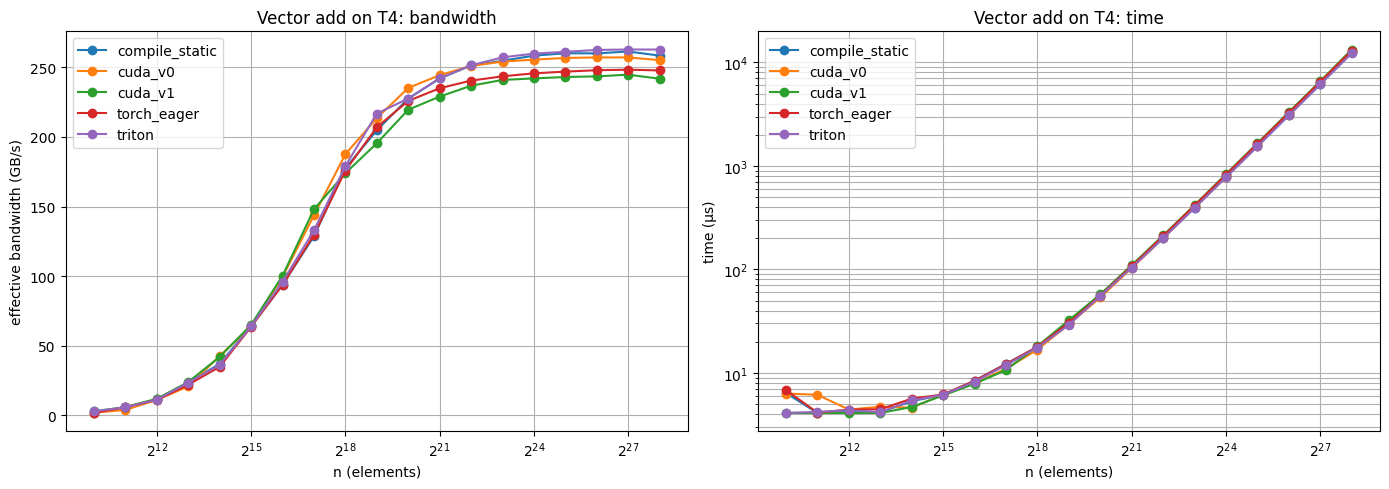

In [60]:
import matplotlib.pyplot as plt

df_cuda = pd.read_csv("cuda_vadd.csv", comment="#")
df_all = pd.concat([df_py, df_cuda], ignore_index=True)

# make sure n is a number (handles values written as "2**10" from df_py, and numeric from df_cuda)
df_all["n"] = df_all["n"].apply(lambda x: 2 ** int(x.split("**")[1]) if isinstance(x, str) and "**" in x else x)

# Side-by-side table, plus v1 relative to v0
pivot = df_all.pivot(index="n", columns="impl", values="GB/s")
pivot["v1 / v0"] = pivot["cuda_v1"] / pivot["cuda_v0"]
display(pivot.round(3).rename(index=format_n_as_power_of_2))

# Plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for impl, g in df_all.groupby("impl"):
    g = g.sort_values("n")
    ax1.plot(g["n"], g["GB/s"], marker="o", label=impl)
    ax2.plot(g["n"], g["time_us"], marker="o", label=impl)

ax1.set_xscale("log", base=2)
ax1.set_xlabel("n (elements)")
ax1.set_ylabel("effective bandwidth (GB/s)")
ax1.set_title("Vector add on T4: bandwidth")
ax1.grid(True)
ax1.legend()

ax2.set_xscale("log", base=2)
ax2.set_yscale("log")
ax2.set_xlabel("n (elements)")
ax2.set_ylabel("time (µs)")
ax2.set_title("Vector add on T4: time")
ax2.grid(True, which="both")
ax2.legend()

plt.tight_layout()
plt.savefig("vadd_t4_v0_v1.png", dpi=150)
plt.show()

In [25]:
%%writefile profile_eager.py
import torch
n = 2**24
a = torch.empty(n, device="cuda")
b = torch.empty(n, device="cuda")
c = torch.empty(n, device="cuda")
torch.add(a, b, out=c)
torch.cuda.synchronize()

Writing profile_eager.py


In [26]:
!ncu --section SpeedOfLight --metrics l1tex__t_sectors_pipe_lsu_mem_global_op_ld.sum,l1tex__t_requests_pipe_lsu_mem_global_op_ld.sum ./vadd 0 16777216

==PROF== Connected to process 11205 (/content/vadd)
==PROF== Profiling "vecAddKernel" - 0: 0%....50%....100% - 10 passes
==PROF== Disconnected from process 11205
[11205] vadd@127.0.0.1
  vecAddKernel(float *, float *, float *, int) (65536, 1, 1)x(256, 1, 1), Context 1, Stream 7, Device 0, CC 7.5
    Section: Command line profiler metrics
    ----------------------------------------------- ----------- ------------
    Metric Name                                     Metric Unit Metric Value
    ----------------------------------------------- ----------- ------------
    l1tex__t_requests_pipe_lsu_mem_global_op_ld.sum                1,048,576
    l1tex__t_sectors_pipe_lsu_mem_global_op_ld.sum       sector    4,194,304
    ----------------------------------------------- ----------- ------------

    Section: GPU Speed Of Light Throughput
    ----------------------- ----------- ------------
    Metric Name             Metric Unit Metric Value
    ----------------------- ----------- --------

In [27]:
!ncu -k regex:elementwise -c 1 --section SpeedOfLight --metrics l1tex__t_sectors_pipe_lsu_mem_global_op_ld.sum,l1tex__t_requests_pipe_lsu_mem_global_op_ld.sum python profile_eager.py

==PROF== Connected to process 11433 (/usr/bin/python3.13)
==PROF== Profiling "vectorized_elementwise_kernel": 0%....50%....100% - 10 passes
==PROF== Disconnected from process 11433
[11433] python3.13@127.0.0.1
  void vectorized_elementwise_kernel<4, CUDAFunctor_add<float>, array<char *, 3>>(int, T2, T3) (16384, 1, 1)x(128, 1, 1), Context 1, Stream 7, Device 0, CC 7.5
    Section: Command line profiler metrics
    ----------------------------------------------- ----------- ------------
    Metric Name                                     Metric Unit Metric Value
    ----------------------------------------------- ----------- ------------
    l1tex__t_requests_pipe_lsu_mem_global_op_ld.sum                  262,144
    l1tex__t_sectors_pipe_lsu_mem_global_op_ld.sum       sector    4,194,304
    ----------------------------------------------- ----------- ------------

    Section: GPU Speed Of Light Throughput
    ----------------------- ----------- ------------
    Metric Name             

In [28]:
!cuobjdump -sass vadd


Fatbin elf code:
arch = sm_75
code version = [1,8]
host = linux
compile_size = 64bit
identifier = vadd.cu 

	code for sm_75
	.target	sm_75


Fatbin elf code:
arch = sm_75
code version = [1,8]
host = linux
compile_size = 64bit
identifier = vadd.cu

	code for sm_75
	.target	sm_75

		Function : _Z15vecAddKernel_v1PfS_S_i
	.headerflags	@"EF_CUDA_SM75 EF_CUDA_VIRTUAL_SM(EF_CUDA_SM75)"
        /*0000*/                   MOV R1, c[0x0][0x28] ;                        /* 0x00000a0000017a02 */
                                                                                 /* 0x000fe40000000f00 */
        /*0010*/                   S2R R2, SR_CTAID.X ;                          /* 0x0000000000027919 */
                                                                                 /* 0x000e220000002500 */
        /*0020*/                   MOV R0, c[0x0][0x178] ;                       /* 0x00005e0000007a02 */
                                                                                 /* 0x

In [29]:
!cuobjdump -sass vadd | grep -E "Function|LDG|STG"

		Function : _Z15vecAddKernel_v1PfS_S_i
        /*00c0*/              @!P0 LDG.E.128.SYS R12, [R2] ;                     /* 0x00000000020c8381 */
        /*00d0*/              @!P0 LDG.E.128.SYS R16, [R4] ;                     /* 0x0000000004108381 */
        /*0170*/              @!P0 STG.E.128.SYS [R6], R12 ;                     /* 0x0000000c06008386 */
        /*01c0*/                   LDG.E.SYS R4, [R4] ;                          /* 0x0000000004047381 */
        /*01d0*/                   LDG.E.SYS R3, [R2] ;                          /* 0x0000000002037381 */
        /*0200*/                   STG.E.SYS [R6], R9 ;                          /* 0x0000000906007386 */
		Function : _Z12vecAddKernelPfS_S_i
        /*0090*/                   LDG.E.SYS R4, [R4] ;                          /* 0x0000000004047381 */
        /*00a0*/                   LDG.E.SYS R3, [R2] ;                          /* 0x0000000002037381 */
        /*00d0*/                   STG.E.SYS [R6], R9 ;                    

In [51]:
import triton
import triton.language as tl

@triton.autotune(
    configs=[
        triton.Config({"BLOCK": block}, num_warps=warps)
        for block in [256, 512, 1024, 2048, 4096]
        for warps in [2, 4, 8]
    ],
    key=["n"],   # re-tune whenever n changes
)
@triton.jit
def vadd_triton_kernel(a_ptr, b_ptr, c_ptr, n, BLOCK: tl.constexpr):
    pid = tl.program_id(0)                     # which block this is (like blockIdx.x)
    offs = pid * BLOCK + tl.arange(0, BLOCK)   # the BLOCK element indices this block handles
    mask = offs < n                            # the bounds check, for the whole block at once
    a = tl.load(a_ptr + offs, mask=mask)
    b = tl.load(b_ptr + offs, mask=mask)
    tl.store(c_ptr + offs, a + b, mask=mask)


def triton_add(a, b, c):
    n = a.numel()
    grid = lambda meta: (triton.cdiv(n, meta["BLOCK"]),)   # number of blocks, from the chosen BLOCK
    vadd_triton_kernel[grid](a, b, c, n)

In [52]:
def check_into(fn, ref, sizes=(1, 127, 4096, 2**24 + 3)):
    for n in sizes:
        a = torch.randn(n, device="cuda")
        b = torch.randn(n, device="cuda")
        c = torch.empty_like(a)
        fn(a, b, c)
        torch.testing.assert_close(c, ref(a, b))
    print(f"{fn.__name__}: {len(sizes)} sizes passed")

check_into(triton_add, vadd_ref)

triton_add: 4 sizes passed


In [53]:
df_py = bench({
    "torch_eager": torch_eager,
    "compile_static": compile_static,
    "triton": triton_add,
}, sizes)

{'gpu': 'Tesla T4, 580.82.07, 1185 MHz, 5000 MHz, Enabled', 'torch': '2.11.0+cu130', 'cuda': '13.0', 'triton': '3.6.0', 'python': '3.13.15'}


In [54]:
for n in [2**12, 2**17, 2**24]:
    a = torch.randn(n, device="cuda"); b = torch.randn(n, device="cuda"); c = torch.empty_like(a)
    triton_add(a, b, c)
    print(n, vadd_triton_kernel.best_config)

4096 BLOCK: 512, num_warps: 2, num_ctas: 1, num_stages: 3, maxnreg: None
131072 BLOCK: 4096, num_warps: 4, num_ctas: 1, num_stages: 3, maxnreg: None
16777216 BLOCK: 256, num_warps: 8, num_ctas: 1, num_stages: 3, maxnreg: None


In [61]:
def compile_triton(n, BLOCK, num_warps):
    a = torch.randn(n, device="cuda")
    b = torch.randn(n, device="cuda")
    c = torch.empty_like(a)
    grid = (triton.cdiv(n, BLOCK),)
    # .fn is the plain kernel underneath the autotuner; launching it returns the compiled kernel
    return vadd_triton_kernel.fn[grid](a, b, c, n, BLOCK=BLOCK, num_warps=num_warps)

k24 = compile_triton(2**24, 256, 8)    # the 2**24 winner
k17 = compile_triton(2**17, 4096, 4)   # the 2**17 winner

for name, k in [("2**24 config", k24), ("2**17 config", k17)]:
    layout = [line for line in k.asm["ttgir"].splitlines() if line.startswith("#blocked")]
    print(name, layout)
    open(f"triton_{name.split()[0].replace('**', '_')}.cubin", "wb").write(k.asm["cubin"])

2**24 config ['#blocked = #ttg.blocked<{sizePerThread = [1], threadsPerWarp = [32], warpsPerCTA = [8], order = [0]}>']
2**17 config ['#blocked = #ttg.blocked<{sizePerThread = [4], threadsPerWarp = [32], warpsPerCTA = [4], order = [0]}>']


In [62]:
!cuobjdump -sass triton_2_24.cubin | grep -E "LDG|STG"

        /*00a0*/              @!P0 LDG.E.SYS R8, [R2] ;                                /* 0x0000000002088381 */
        /*00b0*/              @!P0 LDG.E.SYS R9, [R4] ;                                /* 0x0000000004098381 */
        /*00f0*/                   STG.E.SYS [R6], R9 ;                                /* 0x0000000906007386 */


In [63]:
!cuobjdump -sass triton_2_17.cubin | grep -E "LDG|STG"

        /*00e0*/              @!P0 LDG.E.128.SYS R52, [R40] ;                           /* 0x0000000028348381 */
        /*00f0*/              @!P0 LDG.E.128.SYS R56, [R60] ;                           /* 0x000000003c388381 */
        /*02a0*/              @!P0 LDG.E.128.SYS R24, [R40+0x800] ;                     /* 0x0008000028188381 */
        /*02b0*/              @!P0 LDG.E.128.SYS R28, [R60+0x800] ;                     /* 0x000800003c1c8381 */
        /*02f0*/              @!P1 LDG.E.128.SYS R20, [R40+0x1000] ;                    /* 0x0010000028149381 */
        /*0330*/              @!P2 LDG.E.128.SYS R16, [R40+0x1800] ;                    /* 0x001800002810a381 */
        /*0370*/              @!P3 LDG.E.128.SYS R12, [R40+0x2000] ;                    /* 0x00200000280cb381 */
        /*03b0*/              @!P4 LDG.E.128.SYS R8, [R40+0x2800] ;                     /* 0x002800002808c381 */
        /*03c0*/              @!P5 LDG.E.128.SYS R4, [R40+0x3000] ;                     /* 0x003